## Vício de estudantes em relação às redes sociais.
Link do kaggle: [datasets/adilshamim8/social-media-addiction-vs-relationships](https://www.kaggle.com/datasets/adilshamim8/social-media-addiction-vs-relationships/data)

### Instalação

In [ ]:
!pip install kagglehub matplotlib numpy pandas

### Dados

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from pathlib import Path

ROOT_PATH = Path('.').resolve().absolute().parent
ROOT = ROOT_PATH.__str__()
ASSETS = ROOT_PATH / 'assets/'

In [5]:
df = pd.read_csv(ASSETS / 'Students Social Media Addiction.csv')

In [6]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [12]:
df = df.rename(columns={
    "Student_ID": "id",
    "Age": "idade",
    "Gender": "sexo",
    "Academic_Level": "escolaridade",
    "Country": "país",
    "Avg_Daily_Usage_Hours": "horas_diarias",
    "Most_Used_Platform": "plataforma",
    "Affects_Academic_Performance": "afeta_notas",
    "Sleep_Hours_Per_Night": "horas_de_sono",
    "Mental_Health_Score": "saúde_mental",
    "Relationship_Status": "relação",
    "Conflicts_Over_Social_Media": "conflito_em_redes",
    "Addicted_Score": "grau_de_vicio"
})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 705 non-null    int64  
 1   idade              705 non-null    int64  
 2   sexo               705 non-null    str    
 3   escolaridade       705 non-null    str    
 4   país               705 non-null    str    
 5   horas_diarias      705 non-null    float64
 6   plataforma         705 non-null    str    
 7   afeta_notas        705 non-null    str    
 8   horas_de_sono      705 non-null    float64
 9   saúde_mental       705 non-null    int64  
 10  relação            705 non-null    str    
 11  conflito_em_redes  705 non-null    int64  
 12  grau_de_vicio      705 non-null    int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 71.7 KB


In [20]:
df["sexo"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [ ]:
df["relação"] = df["relação"].replace({
    "In Relationship": "em relação",
    "Single": "solteiro",
    "Complicated": "complicado"
})
df["afeta_notas"] = df["afeta_notas"].replace({
    "Yes": "sim",
    "No": "não"
})
df["sexo"] = df["sexo"].replace({
    "Male": "M",
    "Female": "F"
})

df.head()

,id,idade,sexo,escolaridade,país,horas_diarias,plataforma,afeta_notas,horas_de_sono,saúde_mental,relação,conflito_em_redes,grau_de_vicio
0,1,19,F,Undergraduate,Bangladesh,5.2,Instagram,sim,6.5,6,em relação,3,8
1,2,22,M,Graduate,India,2.1,Twitter,não,7.5,8,solteiro,0,3
2,3,20,F,Undergraduate,USA,6.0,TikTok,sim,5.0,5,complicado,4,9
3,4,18,M,High School,UK,3.0,YouTube,não,7.0,7,solteiro,1,4
4,5,21,M,Graduate,Canada,4.5,Facebook,sim,6.0,6,em relação,2,7


### Gráficos

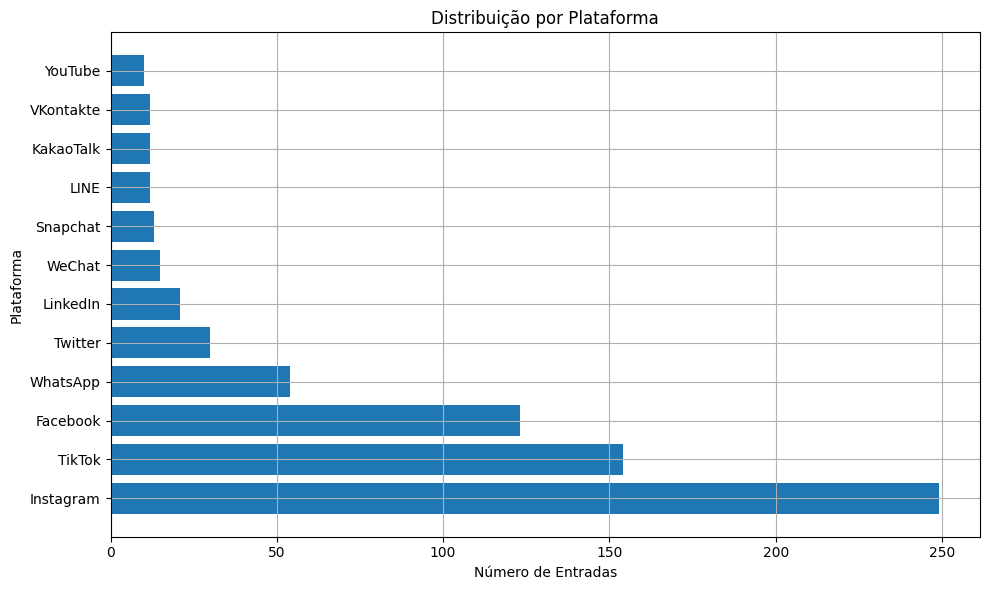

In [35]:
contador: dict[str, int] = df["plataforma"].value_counts().to_dict() # type: ignore

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.barh(list(contador.keys()), list(contador.values()))
plt.xlabel('Número de Entradas')
plt.ylabel('Plataforma')
plt.title('Distribuição por Plataforma')
plt.tight_layout()
plt.show()

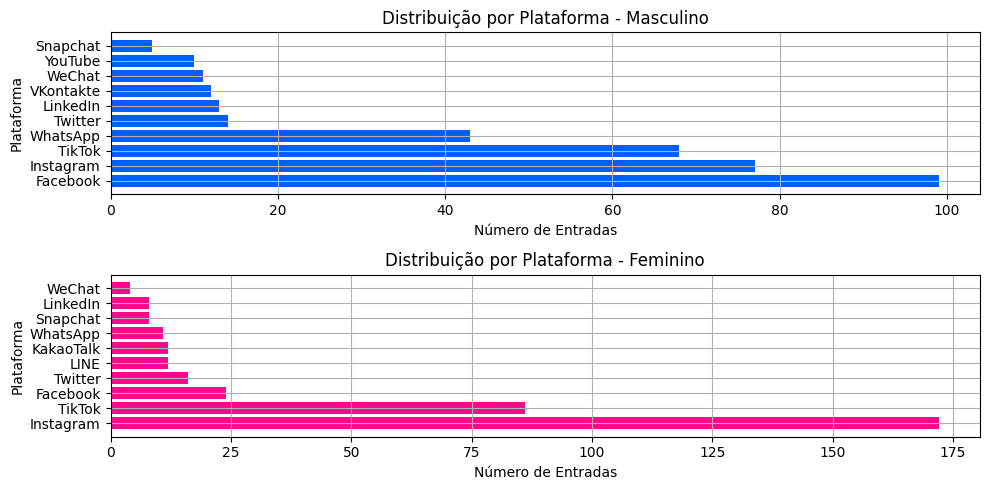

In [42]:
contador_m: dict[str, int] = df.query("sexo == 'M'")["plataforma"].value_counts().to_dict() # type: ignore
contador_f: dict[str, int] = df.query("sexo == 'F'")["plataforma"].value_counts().to_dict() # type: ignore

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

ax1.grid(True)
ax1.barh(list(contador_m.keys()), list(contador_m.values()), color="#005eff")
ax1.set_xlabel('Número de Entradas')
ax1.set_ylabel('Plataforma')
ax1.set_title('Distribuição por Plataforma - Masculino')

ax2.grid(True)
ax2.barh(list(contador_f.keys()), list(contador_f.values()), color='#ff088c')
ax2.set_xlabel('Número de Entradas')
ax2.set_ylabel('Plataforma')
ax2.set_title('Distribuição por Plataforma - Feminino')

plt.tight_layout()
plt.show()

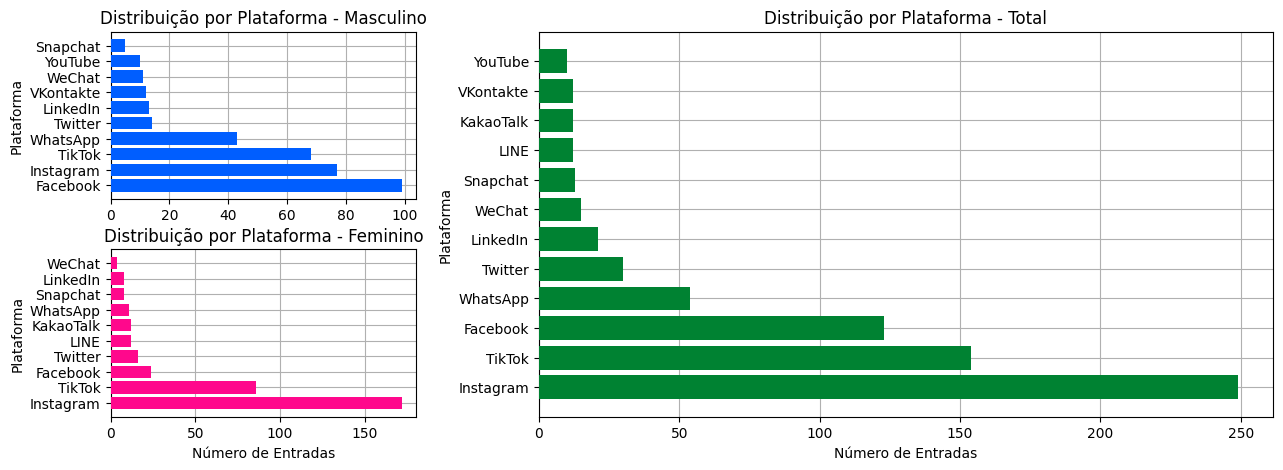

In [61]:
contador_m: dict[str, int] = df.query("sexo == 'M'")["plataforma"].value_counts().to_dict() # type: ignore
contador_f: dict[str, int] = df.query("sexo == 'F'")["plataforma"].value_counts().to_dict() # type: ignore
contador_total: dict[str, int] = df["plataforma"].value_counts().to_dict() # type: ignore

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.3, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[:, 1:])

ax1.grid(True, zorder=0)
ax1.barh(list(contador_m.keys()), list(contador_m.values()), color="#005eff", zorder=3)
ax1.set_ylabel('Plataforma')
ax1.set_title('Distribuição por Plataforma - Masculino')
ax1.set_axisbelow(True)

ax2.grid(True, zorder=0)
ax2.barh(list(contador_f.keys()), list(contador_f.values()), color='#ff088c', zorder=3)
ax2.set_xlabel('Número de Entradas')
ax2.set_ylabel('Plataforma')
ax2.set_title('Distribuição por Plataforma - Feminino')
ax2.set_axisbelow(True)

ax3.grid(True, zorder=0)
ax3.barh(list(contador_total.keys()), list(contador_total.values()), color='#008232', zorder=3)
ax3.set_xlabel('Número de Entradas')
ax3.set_ylabel('Plataforma')
ax3.set_title('Distribuição por Plataforma - Total')
ax3.set_axisbelow(True)

plt.show()